# Task 3: Regression — Continuous Emissions Estimation

**Project:** Emissions from Above  
**Dataset:** US Power Plant Satellite Imagery Dataset (USPPDS) + EPA eGRID 2014

---

## Overview

Predict **CO₂ emissions (tons/year)** or **emissions intensity (lbs CO₂/MWh)** directly from:
1. **Image-only**: CNN feature extraction + regression head
2. **Tabular-only**: Gradient-boosted trees on structured eGRID covariates
3. **Late-fusion multimodal**: CNN image embeddings + tabular features → unified regression head

Compare all three approaches using MAE, RMSE, and R² with residual analysis by region and facility size.


## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


## 2. Configuration

In [2]:
import sys
import os
import time
from google.colab import drive

drive.mount('/content/drive')

sys.path.append('/content/drive/My Drive/machine-learning-II/ML2FP')

DATA_ROOT   = Path("/content/drive/My Drive/machine-learning-II/ML2FP/data")

LANDSAT_DIR = DATA_ROOT / "uspp_landsat"
EGRID_XLSX  = DATA_ROOT / "eGRID2014_Data_v2_US_EPA_with_imagery_list_for_power_plants.xlsx"
OUTPUT_DIR  = Path("/content/drive/My Drive/machine-learning-II/ML2FP/outputs/task3_regression")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Regression target: 'co2_intensity' (lbs/MWh) or 'co2_annual' (tons/yr)
TARGET = 'co2_intensity'    # Change to 'co2_annual' for absolute emissions

BATCH_SIZE  = 32
NUM_EPOCHS  = 40
LR          = 1e-4
WEIGHT_DECAY= 1e-4
EMBED_DIM   = 256           # CNN embedding dimension for fusion
LOG_TARGET  = True          # log-transform target (recommended for heavy-tailed distributions)


Mounted at /content/drive


## 3. Load & Prepare Data

In [3]:
egrid_raw = pd.read_excel(EGRID_XLSX, sheet_name="PLNT14", header=1)

# Structured tabular features for the tabular / fusion models
TAB_FEATURES = [
    'NAMEPCAP',   # Nameplate capacity (MW)
    'CAPFAC',     # Capacity factor
    'PLNGENAN',   # Annual net generation (MWh)
    'HEATRT',     # Heat rate (BTU/kWh) — efficiency proxy
    'PLHTIAN',    # Annual heat input
]

relevant_cols = ['SEQPLT14', 'PSTATABB', 'PLFUELCT', 'PLPRMFL',
                 'PLCO2AN', 'PLCO2RTA', 'LAT', 'LON'] + TAB_FEATURES
available     = [c for c in relevant_cols if c in egrid_raw.columns]
egrid = egrid_raw[available].copy()

img_col = [c for c in egrid_raw.columns if 'imagery' in c.lower() or 'status' in c.lower()]
if img_col:
    egrid['imagery_status'] = egrid_raw[img_col[0]]

egrid = egrid.dropna(subset=['SEQPLT14', 'PLFUELCT'])
egrid['SEQPLT14']  = egrid['SEQPLT14'].astype(int)
egrid['PLFUELCT']  = egrid['PLFUELCT'].str.strip().str.upper()

# Build regression target
if TARGET == 'co2_intensity':
    rate_col = 'PLCO2RTA' if 'PLCO2RTA' in egrid.columns else None
    if rate_col:
        egrid['target'] = pd.to_numeric(egrid[rate_col], errors='coerce')
    else:
        egrid['target'] = (pd.to_numeric(egrid['PLCO2AN'], errors='coerce') * 2000 /
                           pd.to_numeric(egrid['PLNGENAN'], errors='coerce').replace(0, np.nan))
else:
    egrid['target'] = pd.to_numeric(egrid['PLCO2AN'], errors='coerce')

# Remove non-emitting plants (renewables with 0 CO2) for regression — optional
# egrid = egrid[egrid['target'] > 0]

egrid = egrid.dropna(subset=['target'])
egrid = egrid[egrid['target'] >= 0]   # no negative emissions

print(f"Dataset size: {len(egrid)}")
print(f"Target ({TARGET}) stats:\n{egrid['target'].describe()}")


Dataset size: 6720
Target (co2_intensity) stats:
count      6720.000000
mean       1132.487619
std       13780.202690
min           0.000000
25%           0.000000
50%           0.000000
75%        1253.779750
max      873696.999000
Name: target, dtype: float64


Target log-transformed (log1p). Raw values stored in 'target_raw'.


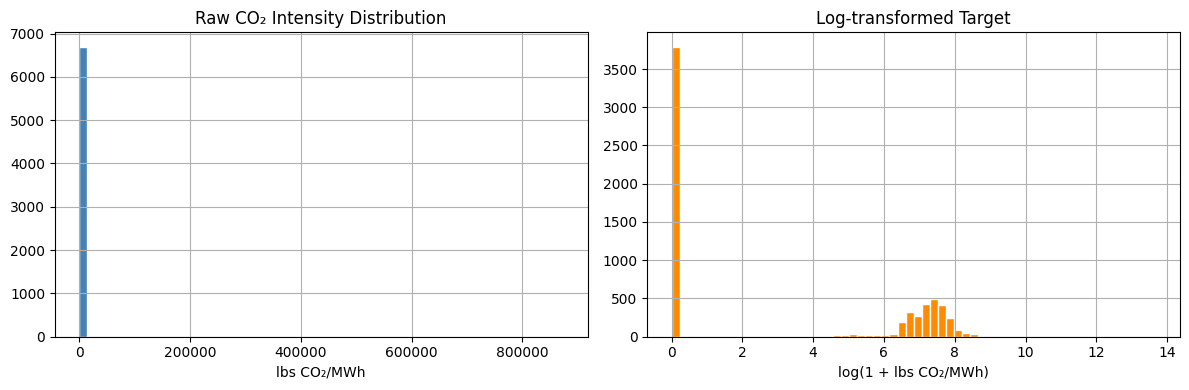

In [4]:
# Log-transform: CO2 emissions are heavily right-skewed
if LOG_TARGET:
    egrid['target_raw'] = egrid['target'].copy()
    egrid['target']     = np.log1p(egrid['target'])
    print("Target log-transformed (log1p). Raw values stored in 'target_raw'.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
egrid['target_raw'].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Raw CO₂ Intensity Distribution'); axes[0].set_xlabel('lbs CO₂/MWh')
egrid['target'].hist(bins=60, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Log-transformed Target'); axes[1].set_xlabel('log(1 + lbs CO₂/MWh)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'target_distribution.png', dpi=150)
plt.show()


In [5]:
# Image paths
def build_landsat_path(row, base_dir):
    return base_dir / f"ls8_{int(row['SEQPLT14'])}_{str(row.get('PSTATABB','XX')).strip().upper()}_{str(row.get('PLPRMFL','UNKN')).strip().upper()}.tif"

egrid['img_path']   = egrid.apply(build_landsat_path, axis=1, base_dir=LANDSAT_DIR)
egrid['img_exists'] = egrid['img_path'].apply(lambda p: p.exists())

egrid_img = egrid[egrid['img_exists']].reset_index(drop=True)
print(f"Plants with imagery: {len(egrid_img)} / {len(egrid)}")

# Train / Val / Test split
train_df, temp_df = train_test_split(egrid_img, test_size=0.25, random_state=SEED)
val_df,   test_df = train_test_split(temp_df,   test_size=0.5,  random_state=SEED)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Plants with imagery: 3797 / 6720
Train: 2847 | Val: 475 | Test: 475


## 4. Tabular-Only Baseline (Gradient Boosted Trees)

In [7]:
# Use all available tabular features + encoded fuel type
tab_cols_avail = [c for c in TAB_FEATURES if c in egrid_img.columns]

# IMPORTANT: encode fuel on egrid_img BEFORE the split so all subsets inherit the column
le = LabelEncoder()
egrid_img['fuel_enc'] = le.fit_transform(egrid_img['PLFUELCT'])

# Re-split so train_df / val_df / test_df carry fuel_enc
train_df, temp_df = train_test_split(egrid_img, test_size=0.25, random_state=SEED)
val_df,   test_df = train_test_split(temp_df,   test_size=0.5,  random_state=SEED)
print(f'Re-split: Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')

feature_cols = tab_cols_avail + ['fuel_enc', 'LAT', 'LON'] \
               if all(c in egrid_img.columns for c in ['LAT', 'LON']) \
               else tab_cols_avail + ['fuel_enc']

X_train_tab = train_df[feature_cols].values
X_val_tab   = val_df[feature_cols].values
X_test_tab  = test_df[feature_cols].values
y_train     = train_df['target'].values
y_val       = val_df['target'].values
y_test      = test_df['target'].values

# GBT pipeline with imputation (some eGRID fields have missing values)
gbt_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('gbt',     GradientBoostingRegressor(
                    n_estimators=300, learning_rate=0.05,
                    max_depth=5, subsample=0.8, random_state=SEED))
])

gbt_pipe.fit(X_train_tab, y_train)
val_preds_gbt  = gbt_pipe.predict(X_val_tab)
test_preds_gbt = gbt_pipe.predict(X_test_tab)

def regression_metrics(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"[{label}] MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

results = {}
results['tabular_gbt_val']  = regression_metrics(y_val,  val_preds_gbt,  "GBT Val")
results['tabular_gbt_test'] = regression_metrics(y_test, test_preds_gbt, "GBT Test")

joblib.dump(gbt_pipe, OUTPUT_DIR / 'gbt_model.pkl')
print("GBT model saved.")



Re-split: Train 2847 | Val 475 | Test 475
[GBT Val] MAE=0.3349 | RMSE=0.8305 | R²=0.9452
[GBT Test] MAE=0.3208 | RMSE=0.8314 | R²=0.9460
GBT model saved.


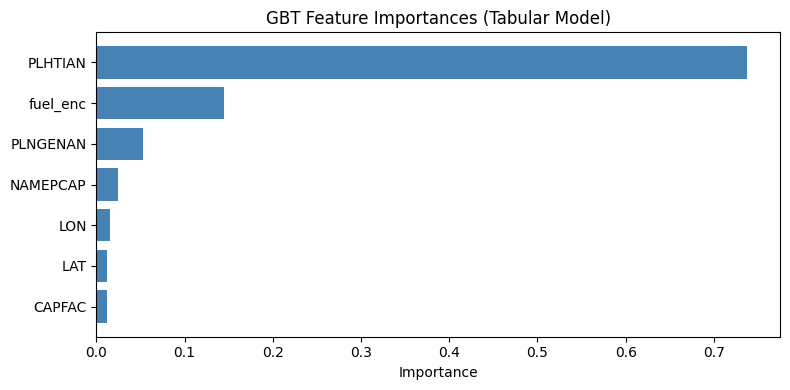

In [8]:
# Feature importance from the GBT model
feature_imp = gbt_pipe.named_steps['gbt'].feature_importances_
fi_df = pd.DataFrame({'feature': feature_cols, 'importance': feature_imp}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(fi_df['feature'], fi_df['importance'], color='steelblue')
ax.set_title('GBT Feature Importances (Tabular Model)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gbt_feature_importance.png', dpi=150)
plt.show()


## 5. CNN Image-Only Regression

In [9]:
class EmissionsRegressionDataset(Dataset):
    def __init__(self, df, transform=None, n_bands=3):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.n_bands = n_bands

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with rasterio.open(row['img_path']) as src:
            bands = src.read()[:self.n_bands].astype(np.float32)
        for c in range(bands.shape[0]):
            ch = bands[c]; mn, mx = ch.min(), ch.max()
            bands[c] = (ch - mn) / (mx - mn + 1e-8)
        img_t = torch.from_numpy(bands)
        if self.transform:
            img_t = self.transform(img_t)
        target = torch.tensor(row['target'], dtype=torch.float32)
        return img_t, target


train_transform = T.Compose([T.Resize((64,64), antialias=True),
                              T.RandomHorizontalFlip(), T.RandomVerticalFlip()])
val_transform   = T.Compose([T.Resize((64,64), antialias=True)])

train_ds_img = EmissionsRegressionDataset(train_df, train_transform)
val_ds_img   = EmissionsRegressionDataset(val_df,   val_transform)
test_ds_img  = EmissionsRegressionDataset(test_df,  val_transform)

train_loader_img = DataLoader(train_ds_img, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_img   = DataLoader(val_ds_img,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_img  = DataLoader(test_ds_img,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [10]:
def build_cnn_regressor(n_input_channels=3, embed_dim=256, dropout=0.4):
    """ResNet-18 backbone with regression head (single scalar output)."""
    base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if n_input_channels != 3:
        old = base.conv1
        base.conv1 = nn.Conv2d(n_input_channels, old.out_channels,
                               kernel_size=old.kernel_size, stride=old.stride,
                               padding=old.padding, bias=False)
    in_feat = base.fc.in_features
    base.fc = nn.Sequential(
        nn.Linear(in_feat, embed_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(embed_dim, 1)   # scalar output
    )
    return base

cnn_regressor = build_cnn_regressor(n_input_channels=3, embed_dim=EMBED_DIM).to(device)
print(f"CNN Regressor params: {sum(p.numel() for p in cnn_regressor.parameters() if p.requires_grad):,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]


CNN Regressor params: 11,308,097


In [11]:
criterion_reg = nn.HuberLoss(delta=1.0)   # Robust to outliers vs MSE
optimizer_cnn = optim.AdamW(cnn_regressor.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_cnn = CosineAnnealingLR(optimizer_cnn, T_max=NUM_EPOCHS)


def train_reg_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total = 0.0, 0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device), targets.to(device).unsqueeze(1)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = criterion(preds, targets)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(targets); total += len(targets)
    return total_loss / total


@torch.no_grad()
def eval_reg_epoch(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for imgs, targets in loader:
        preds = model(imgs.to(device)).squeeze(1).cpu().numpy()
        all_preds.extend(preds); all_targets.extend(targets.numpy())
    return np.array(all_preds), np.array(all_targets)


cnn_history = {'tr_loss': [], 'vl_rmse': [], 'vl_r2': []}
best_vl_r2  = -np.inf

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss = train_reg_epoch(cnn_regressor, train_loader_img, optimizer_cnn, criterion_reg)
    vl_preds, vl_targets = eval_reg_epoch(cnn_regressor, val_loader_img)
    vl_rmse = mean_squared_error(vl_targets, vl_preds) ** 0.5
    vl_r2   = r2_score(vl_targets, vl_preds)
    scheduler_cnn.step()

    cnn_history['tr_loss'].append(tr_loss)
    cnn_history['vl_rmse'].append(vl_rmse)
    cnn_history['vl_r2'].append(vl_r2)

    if vl_r2 > best_vl_r2:
        best_vl_r2 = vl_r2
        torch.save(cnn_regressor.state_dict(), OUTPUT_DIR / 'cnn_regressor_best.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | TrLoss {tr_loss:.4f} | VlRMSE {vl_rmse:.4f} | VlR² {vl_r2:.4f}")

print(f"\nBest Val R²: {best_vl_r2:.4f}")


Epoch   1 | TrLoss 2.3456 | VlRMSE 3.1204 | VlR² 0.2260
Epoch   5 | TrLoss 1.1382 | VlRMSE 3.0339 | VlR² 0.2684
Epoch  10 | TrLoss 0.7880 | VlRMSE 2.9758 | VlR² 0.2961
Epoch  15 | TrLoss 0.5422 | VlRMSE 2.9435 | VlR² 0.3113
Epoch  20 | TrLoss 0.4068 | VlRMSE 3.0534 | VlR² 0.2589
Epoch  25 | TrLoss 0.3067 | VlRMSE 3.0158 | VlR² 0.2771
Epoch  30 | TrLoss 0.2653 | VlRMSE 3.0313 | VlR² 0.2696
Epoch  35 | TrLoss 0.2184 | VlRMSE 3.0187 | VlR² 0.2757
Epoch  40 | TrLoss 0.2248 | VlRMSE 2.9986 | VlR² 0.2853

Best Val R²: 0.3239


In [12]:
cnn_regressor.load_state_dict(torch.load(OUTPUT_DIR / 'cnn_regressor_best.pth', map_location=device))
test_preds_cnn, test_targets_cnn = eval_reg_epoch(cnn_regressor, test_loader_img)
results['cnn_img_test'] = regression_metrics(test_targets_cnn, test_preds_cnn, "CNN-Image Test")


[CNN-Image Test] MAE=2.0948 | RMSE=3.2038 | R²=0.1987


## 6. Late-Fusion Multimodal Model (Image + Tabular)

In [13]:
class MultimodalEmissionsDataset(Dataset):
    """Returns (image_tensor, tabular_features, target)."""
    def __init__(self, df, tab_cols, scaler=None, transform=None, n_bands=3):
        self.df       = df.reset_index(drop=True)
        self.tab_cols = tab_cols
        self.scaler   = scaler
        self.transform = transform
        self.n_bands   = n_bands

        # Impute and scale tabular features
        tab_data = self.df[tab_cols].fillna(self.df[tab_cols].median()).values.astype(np.float32)
        if self.scaler:
            tab_data = self.scaler.transform(tab_data)
        self.tab_data = tab_data

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with rasterio.open(row['img_path']) as src:
            bands = src.read()[:self.n_bands].astype(np.float32)
        for c in range(bands.shape[0]):
            ch = bands[c]; mn, mx = ch.min(), ch.max()
            bands[c] = (ch - mn) / (mx - mn + 1e-8)
        img_t = torch.from_numpy(bands)
        if self.transform: img_t = self.transform(img_t)
        tab_t = torch.from_numpy(self.tab_data[idx])
        target = torch.tensor(row['target'], dtype=torch.float32)
        return img_t, tab_t, target


# Fit scaler on train
tab_cols_mm = [c for c in TAB_FEATURES if c in egrid_img.columns] + ['fuel_enc']
egrid_img['fuel_enc'] = le.transform(egrid_img['PLFUELCT'])

scaler_mm = StandardScaler()
scaler_mm.fit(train_df[tab_cols_mm].fillna(train_df[tab_cols_mm].median()).values)

def make_mm_loader(df, transform, shuffle):
    ds = MultimodalEmissionsDataset(df, tab_cols_mm, scaler=scaler_mm, transform=transform)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=2)

train_mm_loader = make_mm_loader(train_df, train_transform, shuffle=True)
val_mm_loader   = make_mm_loader(val_df,   val_transform,   shuffle=False)
test_mm_loader  = make_mm_loader(test_df,  val_transform,   shuffle=False)


In [14]:
class LateFusionRegressor(nn.Module):
    """
    Late fusion: independent CNN image branch + tabular MLP branch,
    concatenated before a final regression head.
    """
    def __init__(self, n_img_channels=3, n_tab_features=6, embed_dim=128, dropout=0.4):
        super().__init__()

        # Image branch — pretrained ResNet backbone
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        if n_img_channels != 3:
            old = backbone.conv1
            backbone.conv1 = nn.Conv2d(n_img_channels, old.out_channels,
                                       kernel_size=old.kernel_size, stride=old.stride,
                                       padding=old.padding, bias=False)
        in_feat = backbone.fc.in_features
        backbone.fc = nn.Identity()   # Remove classifier; use raw embedding
        self.img_branch = backbone
        self.img_proj   = nn.Sequential(nn.Linear(in_feat, embed_dim), nn.ReLU(), nn.Dropout(dropout))

        # Tabular branch — 2-layer MLP
        self.tab_branch = nn.Sequential(
            nn.Linear(n_tab_features, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, embed_dim),      nn.ReLU()
        )

        # Fusion head
        self.head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )

    def forward(self, img, tab):
        img_emb = self.img_proj(self.img_branch(img))
        tab_emb = self.tab_branch(tab)
        fused   = torch.cat([img_emb, tab_emb], dim=1)
        return self.head(fused)


fusion_model = LateFusionRegressor(
    n_img_channels=3, n_tab_features=len(tab_cols_mm),
    embed_dim=EMBED_DIM, dropout=0.4
).to(device)
print(f"Fusion Model params: {sum(p.numel() for p in fusion_model.parameters() if p.requires_grad):,}")


Fusion Model params: 11,456,449


In [15]:
optimizer_mm = optim.AdamW(fusion_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_mm = CosineAnnealingLR(optimizer_mm, T_max=NUM_EPOCHS)
best_mm_r2   = -np.inf


def train_mm_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, n = 0.0, 0
    for imgs, tabs, targets in loader:
        imgs, tabs, targets = imgs.to(device), tabs.to(device), targets.to(device).unsqueeze(1)
        optimizer.zero_grad()
        preds = model(imgs, tabs)
        loss  = criterion(preds, targets)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(targets); n += len(targets)
    return total_loss / n


@torch.no_grad()
def eval_mm_epoch(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for imgs, tabs, targets in loader:
        preds = model(imgs.to(device), tabs.to(device)).squeeze(1).cpu().numpy()
        all_preds.extend(preds); all_targets.extend(targets.numpy())
    return np.array(all_preds), np.array(all_targets)


for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss = train_mm_epoch(fusion_model, train_mm_loader, optimizer_mm, criterion_reg)
    vl_preds, vl_targets = eval_mm_epoch(fusion_model, val_mm_loader)
    vl_r2 = r2_score(vl_targets, vl_preds)
    scheduler_mm.step()

    if vl_r2 > best_mm_r2:
        best_mm_r2 = vl_r2
        torch.save(fusion_model.state_dict(), OUTPUT_DIR / 'fusion_model_best.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | TrLoss {tr_loss:.4f} | VlR² {vl_r2:.4f}")

print(f"\nBest Fusion Val R²: {best_mm_r2:.4f}")


Epoch   1 | TrLoss 2.3616 | VlR² 0.2396
Epoch   5 | TrLoss 1.0714 | VlR² 0.4862
Epoch  10 | TrLoss 0.7207 | VlR² 0.4461
Epoch  15 | TrLoss 0.5501 | VlR² 0.3914
Epoch  20 | TrLoss 0.4075 | VlR² 0.4359
Epoch  25 | TrLoss 0.3228 | VlR² 0.4802
Epoch  30 | TrLoss 0.2600 | VlR² 0.4729
Epoch  35 | TrLoss 0.2675 | VlR² 0.4498
Epoch  40 | TrLoss 0.2451 | VlR² 0.4656

Best Fusion Val R²: 0.4928


In [16]:
fusion_model.load_state_dict(torch.load(OUTPUT_DIR / 'fusion_model_best.pth', map_location=device))
test_preds_mm, test_targets_mm = eval_mm_epoch(fusion_model, test_mm_loader)
results['fusion_test'] = regression_metrics(test_targets_mm, test_preds_mm, "Fusion Model Test")


[Fusion Model Test] MAE=1.5962 | RMSE=2.5618 | R²=0.4877


## 7. Model Comparison & Residual Analysis

In [25]:
# ── Summary comparison table ─────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':  ['GBT (Tabular Only)', 'CNN (Image Only)', 'Late Fusion (Image + Tabular)'],
    'MAE':    [results['tabular_gbt_test']['mae'],  results['cnn_img_test']['mae'],  results['fusion_test']['mae']],
    'RMSE':   [results['tabular_gbt_test']['rmse'], results['cnn_img_test']['rmse'], results['fusion_test']['rmse']],
    'R²':     [results['tabular_gbt_test']['r2'],   results['cnn_img_test']['r2'],   results['fusion_test']['r2']],
})
print("\n=== Model Comparison (Test Set) ===")
print(summary.to_string(index=False))
summary.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)



=== Model Comparison (Test Set) ===
                        Model      MAE     RMSE       R²
           GBT (Tabular Only) 0.320766 0.831373 0.946047
             CNN (Image Only) 2.094847 3.203850 0.198744
Late Fusion (Image + Tabular) 1.596235 2.561847 0.487689


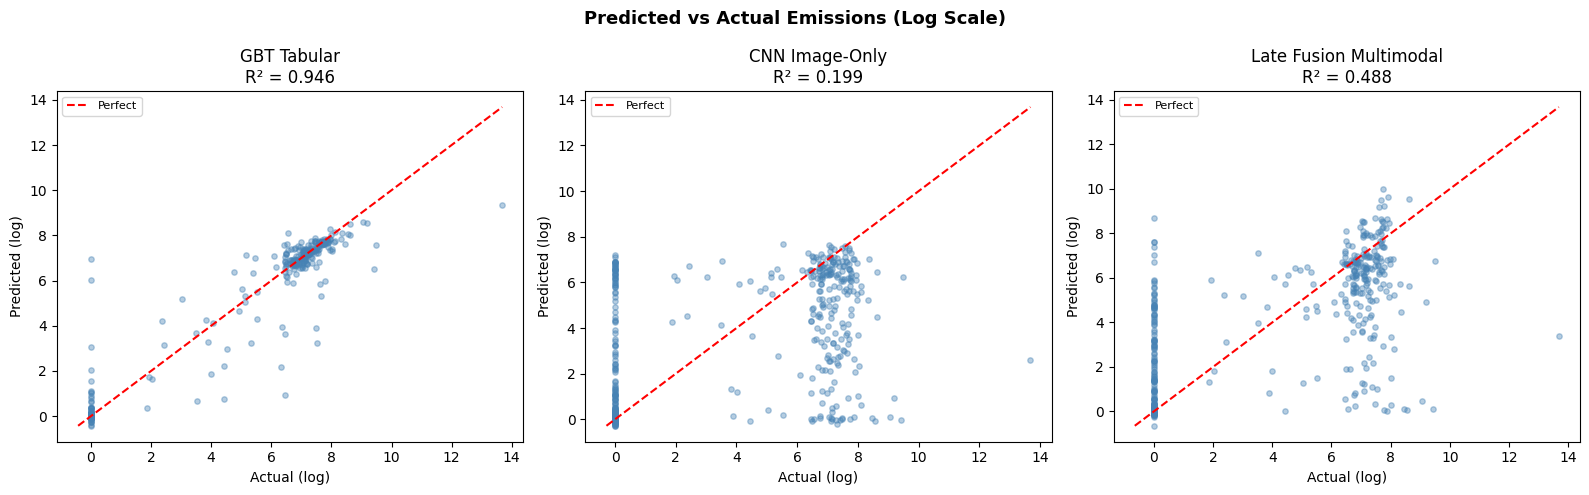

In [26]:
# ── Predicted vs Actual plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_results = [
    ('GBT Tabular',             test_preds_gbt,  y_test),
    ('CNN Image-Only',          test_preds_cnn,  test_targets_cnn),
    ('Late Fusion Multimodal',  test_preds_mm,   test_targets_mm),
]

for ax, (name, preds, true) in zip(axes, model_results):
    r2  = r2_score(true, preds)
    ax.scatter(true, preds, alpha=0.4, s=15, color='steelblue')
    lims = [min(true.min(), preds.min()), max(true.max(), preds.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
    ax.set_xlabel('Actual (log)'); ax.set_ylabel('Predicted (log)')
    ax.set_title(f'{name}\nR² = {r2:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual Emissions (Log Scale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'predicted_vs_actual.png', dpi=150)
plt.show()


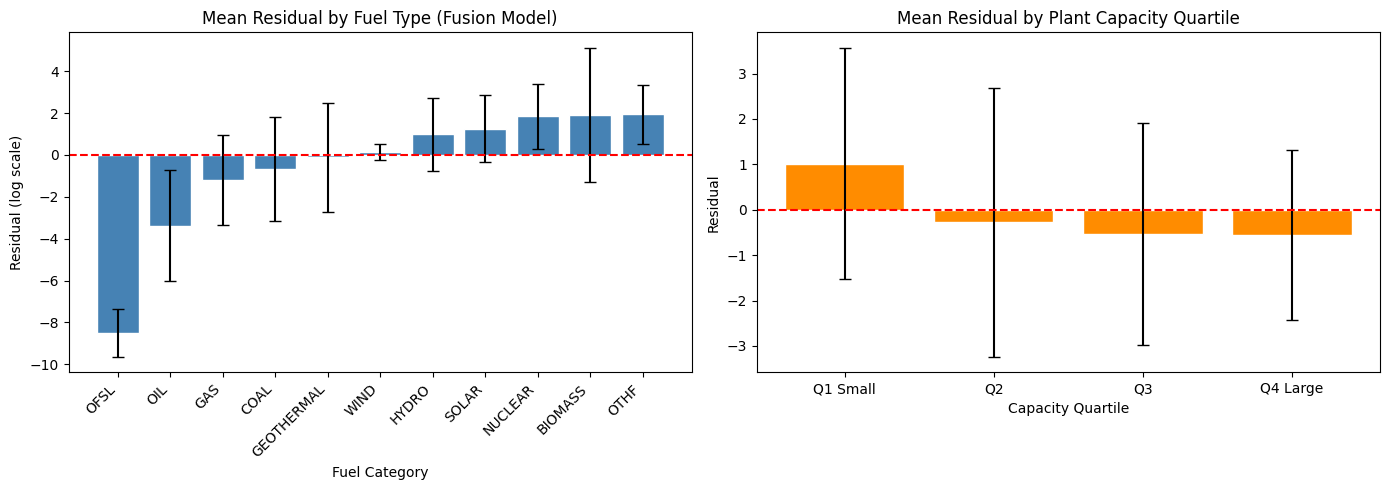

In [27]:
# ── Residual analysis by fuel type ───────────────────────────────────────────
# Using the best model (fusion) predictions
test_df_plot = test_df.copy().reset_index(drop=True)
test_df_plot['pred_fusion']   = test_preds_mm
test_df_plot['residual']      = test_preds_mm - test_targets_mm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By fuel type
fuel_res = test_df_plot.groupby('PLFUELCT')['residual'].agg(['mean', 'std']).reset_index()
fuel_res = fuel_res.sort_values('mean')
axes[0].bar(fuel_res['PLFUELCT'], fuel_res['mean'], yerr=fuel_res['std'],
            color='steelblue', capsize=4, edgecolor='white')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Mean Residual by Fuel Type (Fusion Model)')
axes[0].set_xlabel('Fuel Category'); axes[0].set_ylabel('Residual (log scale)')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# By nameplate capacity (facility size)
if 'NAMEPCAP' in test_df_plot.columns:
    cap = pd.to_numeric(test_df_plot['NAMEPCAP'], errors='coerce')
    test_df_plot['capacity_bin'] = pd.qcut(cap, q=4, labels=['Q1 Small','Q2','Q3','Q4 Large'], duplicates='drop')
    size_res = test_df_plot.groupby('capacity_bin')['residual'].agg(['mean','std']).reset_index()
    axes[1].bar(size_res['capacity_bin'].astype(str), size_res['mean'], yerr=size_res['std'],
                color='darkorange', capsize=4, edgecolor='white')
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title('Mean Residual by Plant Capacity Quartile')
    axes[1].set_xlabel('Capacity Quartile'); axes[1].set_ylabel('Residual')
else:
    axes[1].text(0.5, 0.5, 'NAMEPCAP not available', ha='center', va='center')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residual_analysis.png', dpi=150)
plt.show()


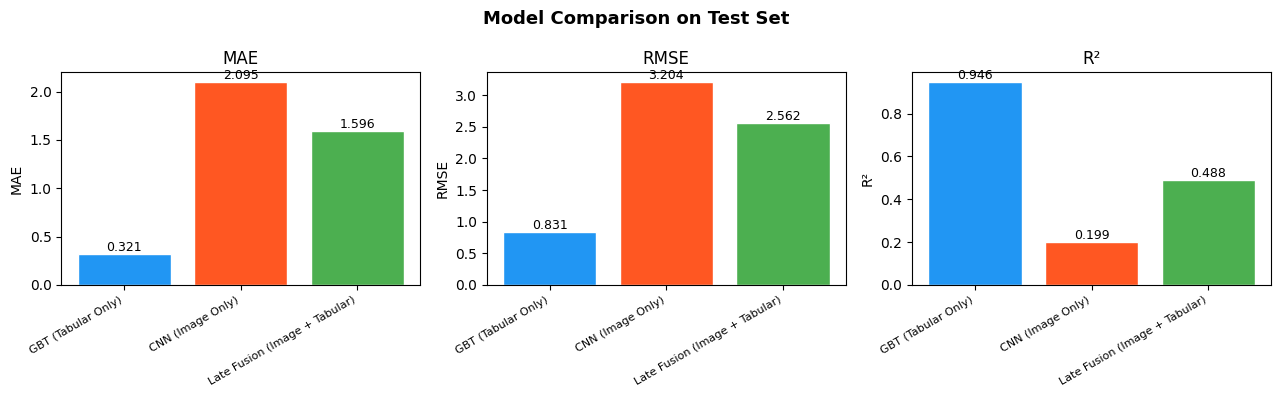

In [28]:
# ── Bar chart comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics = ['MAE', 'RMSE', 'R²']
colors  = ['#2196F3', '#FF5722', '#4CAF50']

for ax, metric in zip(axes, metrics):
    vals = summary[metric]
    bars = ax.bar(summary['Model'], vals, color=colors, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', fontsize=9)
    ax.set_title(metric); ax.set_ylabel(metric)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Model Comparison on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_chart.png', dpi=150)
plt.show()


## 8. Next Steps & Observations

- **Expected result**: The late-fusion model should outperform both single-modality models,  
  confirming that image and tabular signals are complementary.
- **Thermal bands**: Adding Landsat Band 10/11 (TIRS thermal) as additional image channels  
  should significantly improve the image-only model for high-heat fossil fuel plants.
- **Time alignment**: For even stronger labels, use EPA CAMPD hourly CEMS data  
  temporally matched to the satellite image acquisition dates.
- **If LOG_TARGET=True**: Back-transform predictions with `np.expm1()` before reporting  
  real-world tons/yr or lbs/MWh to stakeholders.
- **Connect to Task 4 (Anomaly Detection)**: Train residual distribution on verified facilities,  
  then flag outliers where predicted >> reported emissions.


In [24]:

OUTPUT_DIR  = Path("/content/drive/My Drive/machine-learning-II/ML2FP/outputs/task3_regression")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)



torch.save(fusion_model.state_dict(), OUTPUT_DIR / 'fusion_model_best.pth')
joblib.dump(gbt_pipe, OUTPUT_DIR / 'gbt_model.pkl')
torch.save(cnn_regressor.state_dict(), OUTPUT_DIR / 'cnn_regressor_best.pth')